<p align="center">
    <span style="font-size:2.5em; font-weight:bold;">
        eFleetPlan - Optimal infrastructure and fleet operation of electric LCV
    </span>
</p>

<p align="center">
    <span style="font-size:1.5em; font-weight:bold;">
        Carolina Gil Ribeiro, Jagruti Thakur
    </span>
</p>

## 1. FLEET OPERATIONS simulation

### 1.1. Importing dependencies

In [1]:
from pathlib import Path
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    """Find project root by looking for common project markers."""
    for parent in [start, *start.parents]:
        if (parent / "src").exists():
            return parent
        if (parent / "pyproject.toml").exists():
            return parent
        if (parent / "setup.py").exists():
            return parent

    raise FileNotFoundError("Could not find project root.")


# Find project root automatically
PROJECT_ROOT = find_project_root(Path.cwd())
project_root = PROJECT_ROOT  # backwards-compatible alias used in later cells

# Add project root to Python path
sys.path.insert(0, str(PROJECT_ROOT))

from config._0_supportfiles.config_loader_schedule import load_config, VehicleConfig
from src.efleetplan._1_fleetoperation_simulation.schedule_generation import (
    ScheduleGenerator,
    generate_fleet_schedules,
)

print("All imports OK")

All imports OK


### 1.2. Configurations

#### 1.2.1 Environment parameters

In [2]:
# Changes in the environment configurations can be made in env.yaml

config_dir = PROJECT_ROOT / "config"

env_yaml=project_root/ "test" / "env_TEST.yaml"
run_yaml=project_root/ "test" / "run_FleetSchedule_Config_TEST.yaml"

# IF MORE THAN ONE FLEET
# Define which fleet you want to generate
# Each fleet should correspond to YAML files in the config directory
#run_files = [
#    "run_FleetSchedule_Config_TEST.yaml",
#
##run_yaml=config_dir / run_file
predefined_dir=config_dir / "_1_predefined"


env, run, predefined = load_config(
    env_yaml,
    run_yaml,
    predefined_dir,
)

print("Environment and run configuration loaded successfully:")
print(f"Seed:           {env.seed}")
print(f"Period:         {env.gen_start_date} → {env.gen_end_date}")
print(f"Frequency:      {env.freq}")


Environment and run configuration loaded successfully:
Seed:           42
Period:         2024-01-01 00:00:00 → 2024-12-31 23:00:00
Frequency:      h


#### 1.2.2 Fleet parameters configurations

It is possible to generate diferent types of schedules, adjusting different parameters.
Schedule configuration includes: Type of schedule (a or b), Type of vehicle (Catefory 1 - Renault and Category 2 - Toyota) and Company type.

IMPORTANT: New fleet parameters can be defined/created run.yalm file

#####   - Type of Schedule
Schedules are categorised into two types: Type A, which consists of a continuous schedule, and Type B, which includes two-parts. Various parameters are established to facilitate realistic simulation of daily logistics schedules, including mean departure and return times, standard deviations, and allowable time ranges.

In [3]:
# Resolve the actual configs used in this run (from run.yaml)
print(f"Run: {run.schedule_name}")
print(f"Fleet: {run.n_vehicles} vehicles\n")

# Show schedule configs for each type in the mix
for sched_name, count in run.schedule_mix.items():
    if count == 0:
        continue
    sc = predefined.get_schedule(sched_name, run.custom_schedule)
    print(f"--- ScheduleConfig: '{sched_name}' ({count} vehicles) ---")
    for field, value in sc.model_dump(exclude_none=True).items():
        print(f"  {field}: {value}")
    print()

Run: Test_schedule
Fleet: 4 vehicles

--- ScheduleConfig: 'typea' (4 vehicles) ---
  dep_mean_wd: 8.0
  dep_dev_wd: 1.0
  min_dep: 6.0
  max_dep: 11.0
  ret_mean_wd: 18.0
  ret_dev_wd: 1.0
  min_return_hour: 18.0
  max_return_hour: 22.0
  dep_mean_we: 8.0
  dep_dev_we: 1.0
  ret_mean_we: 18.0
  ret_dev_we: 1.0



#####   - Company type
The values related to company type are defined based on the findings of a survey on light goods vehicles in Sweden conducted by Transport Analysis in 2022. 

notes: Type of transport is defined as the primary use of the LCV and are described as follows: distribution transport for goods or commodities transports with several stops for loading and unloading along the way; Line haul goods or commodities transports, directly from one place to another;  Crafts and services with goods transports include trips for craft or service vehicle that include goods or merchandise to be used or installed in the work; and crafts and services without goods correspond to craft or service trips without goods or merchandise.

notes: Commodity groups were formulated in Light Goods Vehicles 2022 survey to capture the type of goods commonly transported identified by the vehicles.

In [4]:
# Show vehicle configs for each type in the mix
for veh_name, count in run.vehicle_mix.items():
    if count == 0:
        continue
    vc = predefined.get_vehicle(veh_name, run.custom_vehicle)
    print(f"--- VehicleConfig: '{veh_name}' ({count} vehicles) ---")
    for field, value in vc.model_dump().items():
        print(f"  {field}: {value}")
    print()

# Show company config
cc = predefined.get_company(run.company_type, run.custom_company)
print(f"--- CompanyConfig: '{run.company_type}' (all vehicles) ---")
for field, value in cc.model_dump().items():
    print(f"  {field}: {value}")

--- VehicleConfig: 'renault' (2 vehicles) ---
  consumption_mean: 0.192
  consumption_std: 0.1365
  consumption_min: 0.1
  consumption_max: 0.45
  total_cons_clip: 45.0
  battery_capacity: 45.0
  charging_power: 80.0

--- VehicleConfig: 'toyota' (2 vehicles) ---
  consumption_mean: 0.269
  consumption_std: 0.1365
  consumption_min: 0.1
  consumption_max: 0.45
  total_cons_clip: 68.0
  battery_capacity: 68.0
  charging_power: 100.0

--- CompanyConfig: 'distribution' (all vehicles) ---
  avg_distance_wd: 124.0
  dev_distance_wd: 15.0
  avg_distance_we: 73.0
  dev_distance_we: 15.0
  min_distance: 30.0
  max_distance: 300.0
  min_distance_per_step: 1.0
  max_distance_per_step: 50.0
  avg_stops: 52.4
  dev_stops: 11.7


## 1.2. Test validation



In [5]:
# Tests are made to check if are there any invalid values in the parameters, to avoid bugs.

from pydantic import ValidationError

# Test 1: Negative battery capacity
try:
    bad_vc = VehicleConfig(
        consumption_mean=-0.2,  # ← negative!
        consumption_std=0.1, consumption_min=0.1, consumption_max=0.4,
        total_cons_clip=45,battery_capacity=45, charging_power=80
    )
    print('FAIL: ValidationError - check the parameters battery_capacity should not be negative')
except ValidationError as e:
    print(f'Test 1 PASSED: negative value rejected')
    print(f'  Error: {e.errors()[0]["msg"]}')

# Test 2: Typo in field name
try:
    bad_vc = VehicleConfig(
        consumptoin_mean=0.2,  # ← typo!
        consumption_std=0.1, consumption_min=0.1, consumption_max=0.4,
        total_cons_clip=45, 
        battery_capacity=45, charging_power=80
    )
    print('FAIL: ValidationError - check the parameters for typos')
except ValidationError as e:
    print(f'Test 2 PASSED: typo rejected')
    print(f'  Error: {e.errors()[0]["msg"]}')

# Test 3: Mismatched fleet mix
from config._0_supportfiles.config_loader_schedule import RunConfig

try:
    bad_run = RunConfig(
        schedule_name='test', n_vehicles=50,
        schedule_mix={'typea': 30},  # ← sums to 30, not 50!
        vehicle_mix={'renault': 50},
        company_type='distribution'
    )
    print('FAIL: ValidationError - check the parameters for mismatched fleet mix')
except ValidationError as e:
    print(f'Test 3 PASSED: mismatched mix rejected')
    print(f'  Error: {e.errors()[0]["msg"]}')

Test 1 PASSED: negative value rejected
  Error: Input should be greater than 0
Test 2 PASSED: typo rejected
  Error: Field required
Test 3 PASSED: mismatched mix rejected
  Error: Value error, schedule_mix sums to 30, expected n_vehicles=50


## 1.3. Generation of fleet operational schedules

In [6]:
import time

all_results = {}

# Generate the single test scenario defined by env_yaml/run_yaml
print(f"--- Generating: {run.schedule_name} (TEST) ---")
print(f"    {run.n_vehicles} vehicles, company={run.company_type}")

start = time.time()
schedule = generate_fleet_schedules(env, run, predefined)
elapsed = time.time() - start

print(f"    {len(schedule):,} rows in {elapsed:.1f}s")
print()

all_results[run.schedule_name] = schedule

--- Generating: Test_schedule (TEST) ---
    4 vehicles, company=distribution
    35,136 rows in 77.8s



## 1.4. Basic results validation

In [7]:
for name, schedule in all_results.items():
    print(f'{"="*60}')
    print(f'Validation checks: {name}')
    print(f'{"="*60}')

    # Timesteps per vehicle
    expected_steps = len(pd.date_range(start=env.gen_start_date, end=env.gen_end_date, freq=env.freq))
    steps_per_vehicle = schedule.groupby("VehicleID").size()
    assert (steps_per_vehicle == expected_steps).all(), f"{name}: Timestep count mismatch!"
    print(f"✓ All {len(steps_per_vehicle)} vehicles have {expected_steps} timesteps")

    # No negative distances
    assert (schedule['Distance_km'] >= 0).all(), f'{name}: Negative distances found!'
    print('✓ No negative distances')

    # No negative consumption
    assert (schedule['Consumption_kWh'] >= 0).all(), f'{name}: Negative consumption found!'
    print('✓ No negative consumption')

    # Location values
    assert schedule['Location'].isin([0, 1]).all(), f'{name}: Invalid location values!'
    print('✓ Location values valid (0=driving, 1=depot)')

    # Schedule type distribution
    type_counts = schedule.groupby('ScheduleType')['VehicleID'].nunique()
    print(f'\n  Schedule types:')
    for stype, count in type_counts.items():
        print(f'    {stype}: {count} vehicles')

    # Vehicle type distribution
    vtype_counts = schedule.groupby('VehicleType')['VehicleID'].nunique()
    print(f'  Vehicle types:')
    for vtype, count in vtype_counts.items():
        print(f'    {vtype}: {count} vehicles')

    # Quick distance stats
    schedule['date'] = pd.to_datetime(schedule['date'])
    daily = schedule.groupby([schedule['date'].dt.date, 'VehicleID'])['Distance_km'].sum()
    print(f'  Daily distance: mean={daily.mean():.1f}km, std={daily.std():.1f}km, '
          f'min={daily.min():.1f}km, max={daily.max():.1f}km')
    print()

print(f'All {len(all_results)} schedules passed ✓')

Validation checks: Test_schedule
✓ All 4 vehicles have 8784 timesteps
✓ No negative distances
✓ No negative consumption
✓ Location values valid (0=driving, 1=depot)

  Schedule types:
    typea: 4 vehicles
  Vehicle types:
    renault: 2 vehicles
    toyota: 2 vehicles
  Daily distance: mean=87.0km, std=27.6km, min=37.4km, max=186.2km

All 1 schedules passed ✓


## 1.5. Schedules post-processing and visualisation

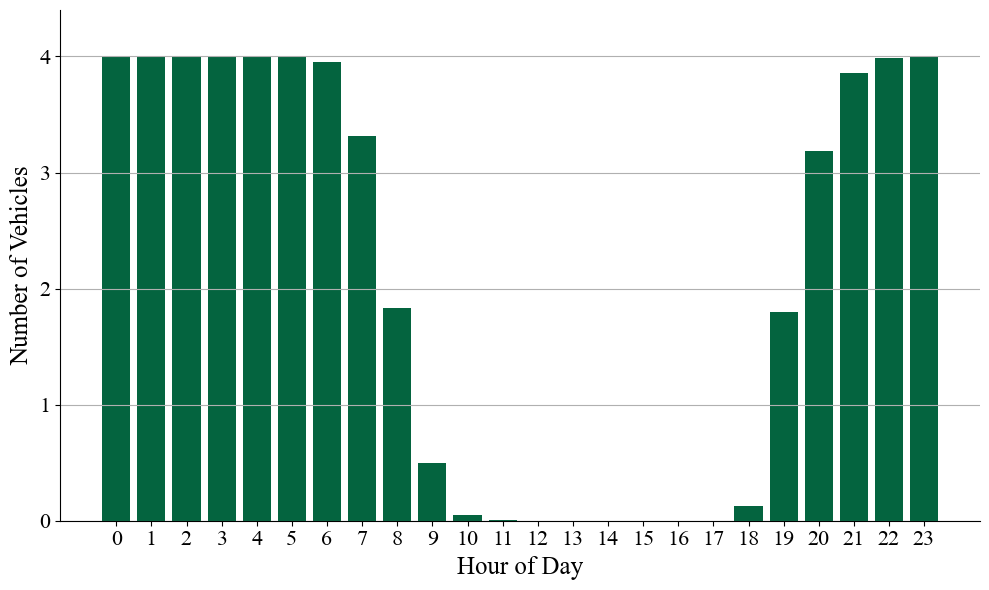

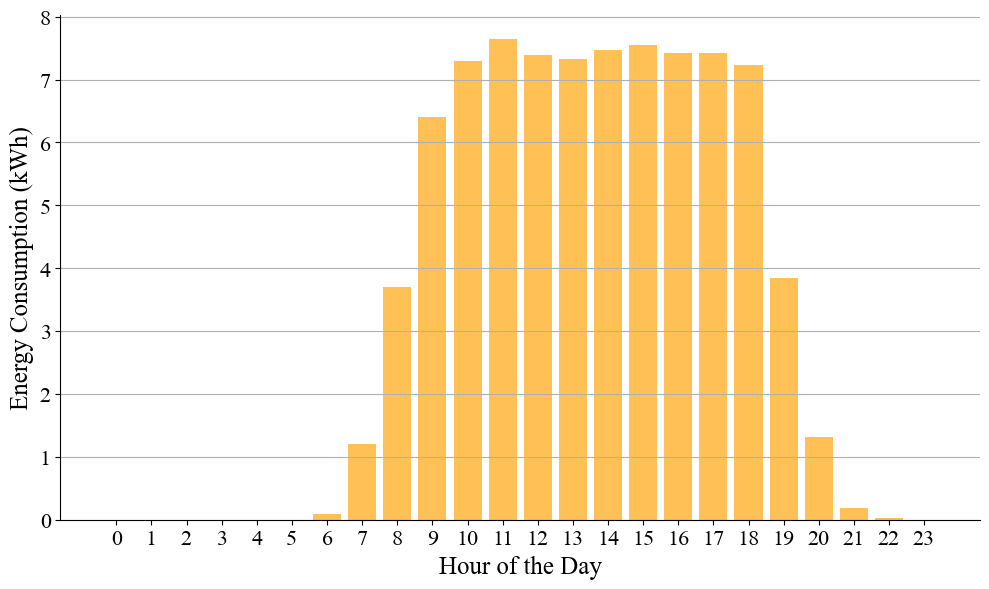

In [8]:
from src.efleetplan._1_fleetoperation_simulation.generate_graphs import generate_graphs

for name in all_results:
    schedule_csv = PROJECT_ROOT / "data" / "Output" / name / f"{name}.csv"
    output_folder = PROJECT_ROOT / "data" / "Output" / name

    generate_graphs(schedule_csv=str(schedule_csv), folder=name, output_folder=str(output_folder))